# Clinical information review of hard-to-classify SERS patients

This notebook reviews subject-level OOF errors using the available clinical export and repeat-measurement quality summaries. Original subject and sample identifiers are not displayed.

## TL;DR

The dataset contains 113 independent subjects and 13,673 repeat spectra, with 121 acquisitions per subject. The repeated measurements improve estimation of each subject's spectral distribution, but they do not create 13,673 independent clinical labels. At the existing 0.40 threshold, the OOF diagnostic has 17 cancer false negatives and 21 non-cancer false positives. The strongest exploratory findings are a high false-positive burden in prostate disease controls and higher repeat-level noise among cancer false negatives.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

candidates = [
    Path('notebooks/aecd_clinical_misclassification_outputs'),
    Path('aecd_clinical_misclassification_outputs'),
]
OUTPUT_DIR = next(path for path in candidates if path.exists())
summary = json.loads((OUTPUT_DIR / 'summary.json').read_text(encoding='utf-8'))
patient_errors = pd.read_csv(OUTPUT_DIR / 'patient_error_review.csv')
hard_cases = pd.read_csv(OUTPUT_DIR / 'hard_case_review.csv')
category_rates = pd.read_csv(OUTPUT_DIR / 'clinical_category_error_rates.csv')
numeric_tests = pd.read_csv(OUTPUT_DIR / 'clinical_numeric_error_tests.csv')
headline = pd.DataFrame([{
    'subjects': summary['data']['subjects'],
    'repeat_spectra': summary['data']['total_repeats'],
    'repeats_per_subject': summary['data']['total_repeats'] / summary['data']['subjects'],
    'qc_pass_rate': summary['data']['qc_pass_rate'],
    'cancer_false_negative_rate': summary['hard_case_counts']['cancer_false_negative_rate'],
    'non_cancer_false_positive_rate': summary['hard_case_counts']['non_cancer_false_positive_rate'],
}])
headline

,subjects,repeat_spectra,repeats_per_subject,qc_pass_rate,cancer_false_negative_rate,non_cancer_false_positive_rate
0,113,13673,121.0,0.945367,0.395349,0.3


## Methods and unit of analysis

The prediction file is joined to the clinical export through the internal subject key recovered from the all-QC repeat summary. The prediction is subject-level OOF probability from the existing QC-passed aligned mean-spectrum run. The positive class is `prostate`; `control` and `prostate disease control` are negative. Error groups are defined at threshold 0.40. Numeric comparisons are exploratory Mann–Whitney tests without multiplicity correction.

In [2]:
outcome_counts = (
    patient_errors.groupby('outcome', sort=False)
    .size()
    .rename('subjects')
    .reset_index()
)
display(outcome_counts)
display(category_rates.loc[category_rates['feature'].isin(['cohort_group', 'grade_group', 'collection_month'])].head(30))
display(numeric_tests.loc[numeric_tests['mann_whitney_p'].notna()].sort_values('mann_whitney_p').head(12))

,outcome,subjects
0,TN,49
1,FP,21
2,TP,26
3,FN,17


,scope,feature,category,n,errors,error_rate
0,all,cohort_group,control,21,6,0.285714
1,all,cohort_group,prostate,43,17,0.395349
2,all,cohort_group,prostate disease control,49,15,0.306122
3,cancer_only,grade_group,1.0,9,3,0.333333
4,cancer_only,grade_group,2.0,7,1,0.142857
5,cancer_only,grade_group,3.0,11,8,0.727273
6,cancer_only,grade_group,4.0,11,4,0.363636
7,cancer_only,grade_group,5.0,5,1,0.200000
19,all,collection_month,2026-03,31,6,0.193548
20,all,collection_month,2026-04,30,9,0.300000


,scope,feature,feature_label,error_group,correct_group,n_error,n_correct,mann_whitney_p,interpretation
6,cancer_only,noise_sigma_mean,Mean repeat noise SD,FN,TP,17,26,0.020203,exploratory; no multiplicity correction
7,cancer_only,noise_sigma_p95,95th percentile repeat noise SD,FN,TP,17,26,0.045541,exploratory; no multiplicity correction
8,cancer_only,qc_distance_max,Maximum QC distance,FN,TP,17,26,0.054216,exploratory; no multiplicity correction
11,non_cancer_only,ua_sg,Urine specific gravity,FP,TN,21,49,0.121951,exploratory; no multiplicity correction
0,cancer_only,psa_raw,PSA raw,FN,TP,17,26,0.183866,exploratory; no multiplicity correction
10,non_cancer_only,ua_ph,Urine pH,FP,TN,21,49,0.322272,exploratory; no multiplicity correction
1,cancer_only,ua_ph,Urine pH,FN,TP,17,26,0.390200,exploratory; no multiplicity correction
2,cancer_only,ua_sg,Urine specific gravity,FN,TP,17,26,0.397140,exploratory; no multiplicity correction
9,non_cancer_only,psa_raw,PSA raw,FP,TN,21,49,0.404821,exploratory; no multiplicity correction
13,non_cancer_only,qc_pass_rate,QC pass rate,FP,TN,21,49,0.698836,exploratory; no multiplicity correction


## Findings

- 15 of 21 false positives are prostate disease controls, indicating that the negative class contains a clinically difficult subgroup.
- Cancer false negatives have median repeat-noise SD 275.0 versus 227.4 for true positives. This is an association in this cohort, not proof that noise causes the error.
- QC pass rate and excluded-repeat count do not separate cancer false negatives from true positives, so the binary QC gate does not capture all repeat inconsistency.
- Grade group 3 has an exploratory error rate of 8/11, but the stratum is small.
- Parsed PSA and overall stage are missing in the local export; collection-month differences should be treated as acquisition or batch sensitivity checks.

,analysis_row,review_reason,cohort_group,prediction_probability,outcome,margin_to_threshold,noise_sigma_mean,noise_sigma_p95,qc_pass_rate,psa_raw,grade_group,collection_month
24,56,misclassified;near_threshold,prostate disease control,0.404631,FP,0.004631,265.933068,343.569242,0.942149,4.80,NaN,2026-06
38,70,near_threshold,prostate disease control,0.388096,TN,0.011904,255.454038,353.449710,0.958678,8.56,NaN,2026-06
25,34,misclassified;near_threshold,prostate disease control,0.413861,FP,0.013861,188.788459,272.582458,0.991736,4.42,NaN,2026-04
26,72,misclassified;near_threshold,prostate,0.385504,FN,0.014496,299.396049,393.912501,0.958678,13.21,3.0,2026-03
39,57,near_threshold,prostate disease control,0.382835,TN,0.017165,263.421494,355.230189,0.933884,6.19,NaN,2026-06
40,35,near_threshold,prostate disease control,0.382349,TN,0.017651,246.340725,409.064588,0.892562,11.77,NaN,2026-04
27,62,misclassified;near_threshold,prostate disease control,0.419870,FP,0.019870,250.042499,351.862261,0.966942,5.63,NaN,2026-05
28,45,misclassified;near_threshold,prostate disease control,0.420358,FP,0.020358,323.330531,472.937788,0.925620,15.02,NaN,2026-05
29,18,misclassified;near_threshold,prostate disease control,0.421364,FP,0.021364,145.691633,189.408338,0.942149,3.46,NaN,2026-03
41,32,near_threshold,prostate disease control,0.378565,TN,0.021435,188.085873,251.010421,0.942149,4.59,NaN,2026-04


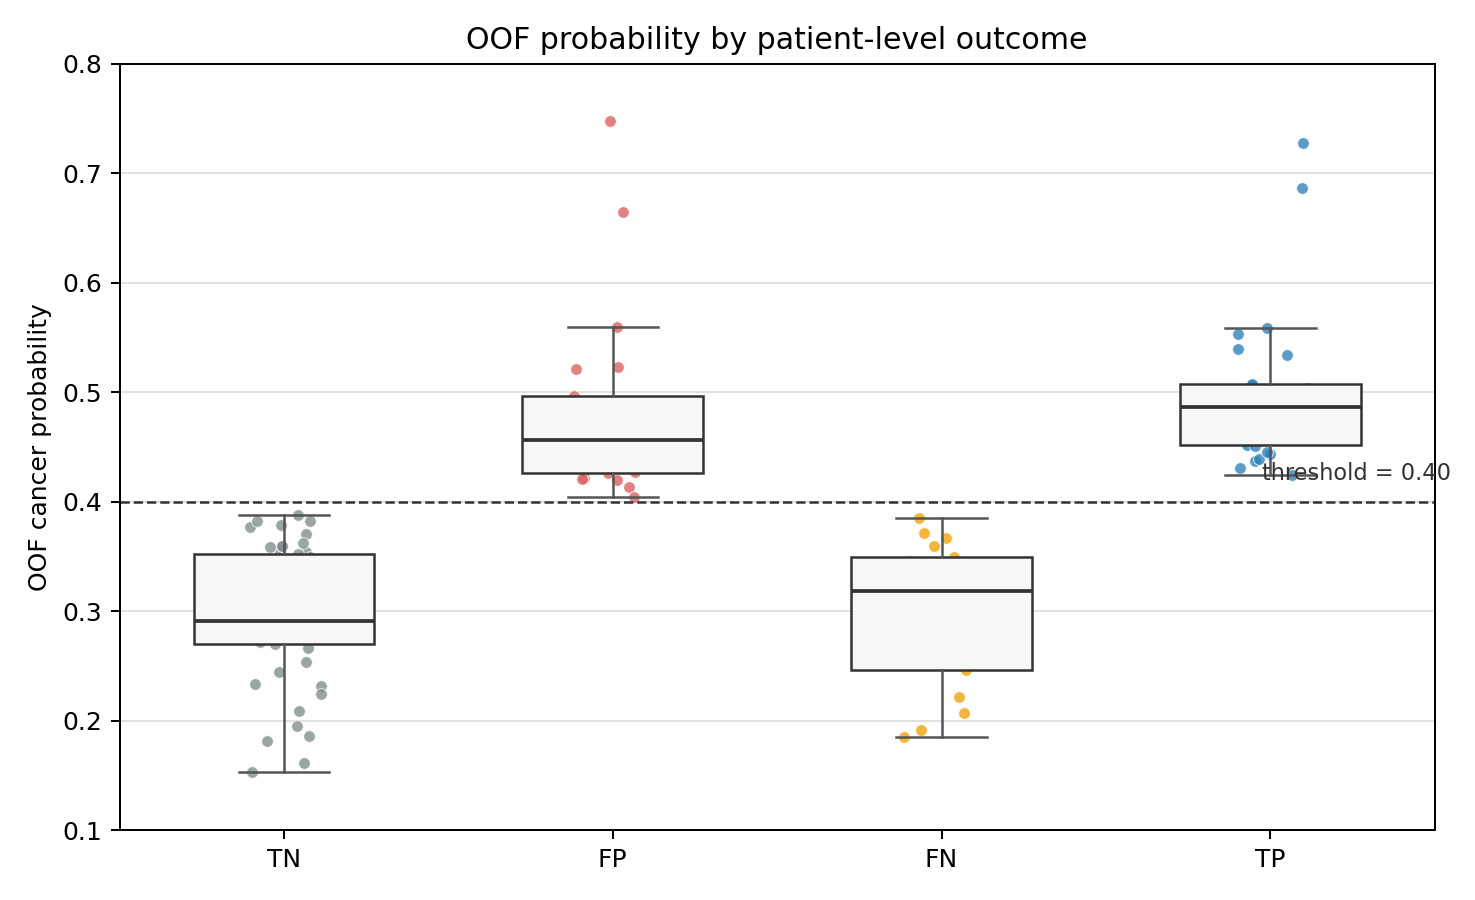

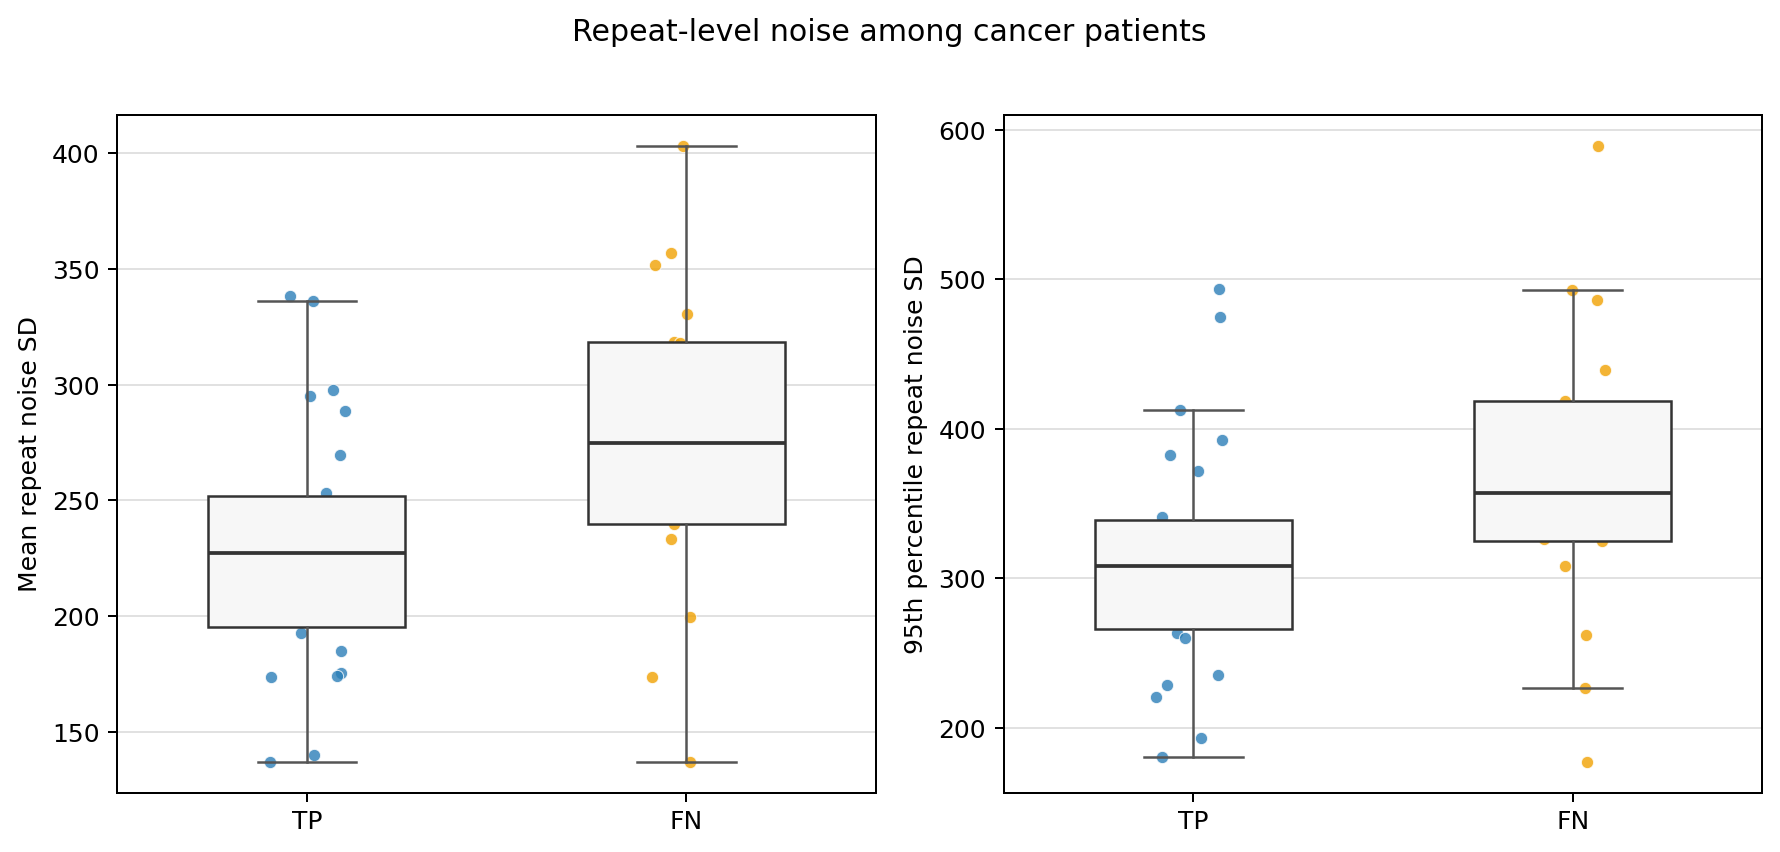

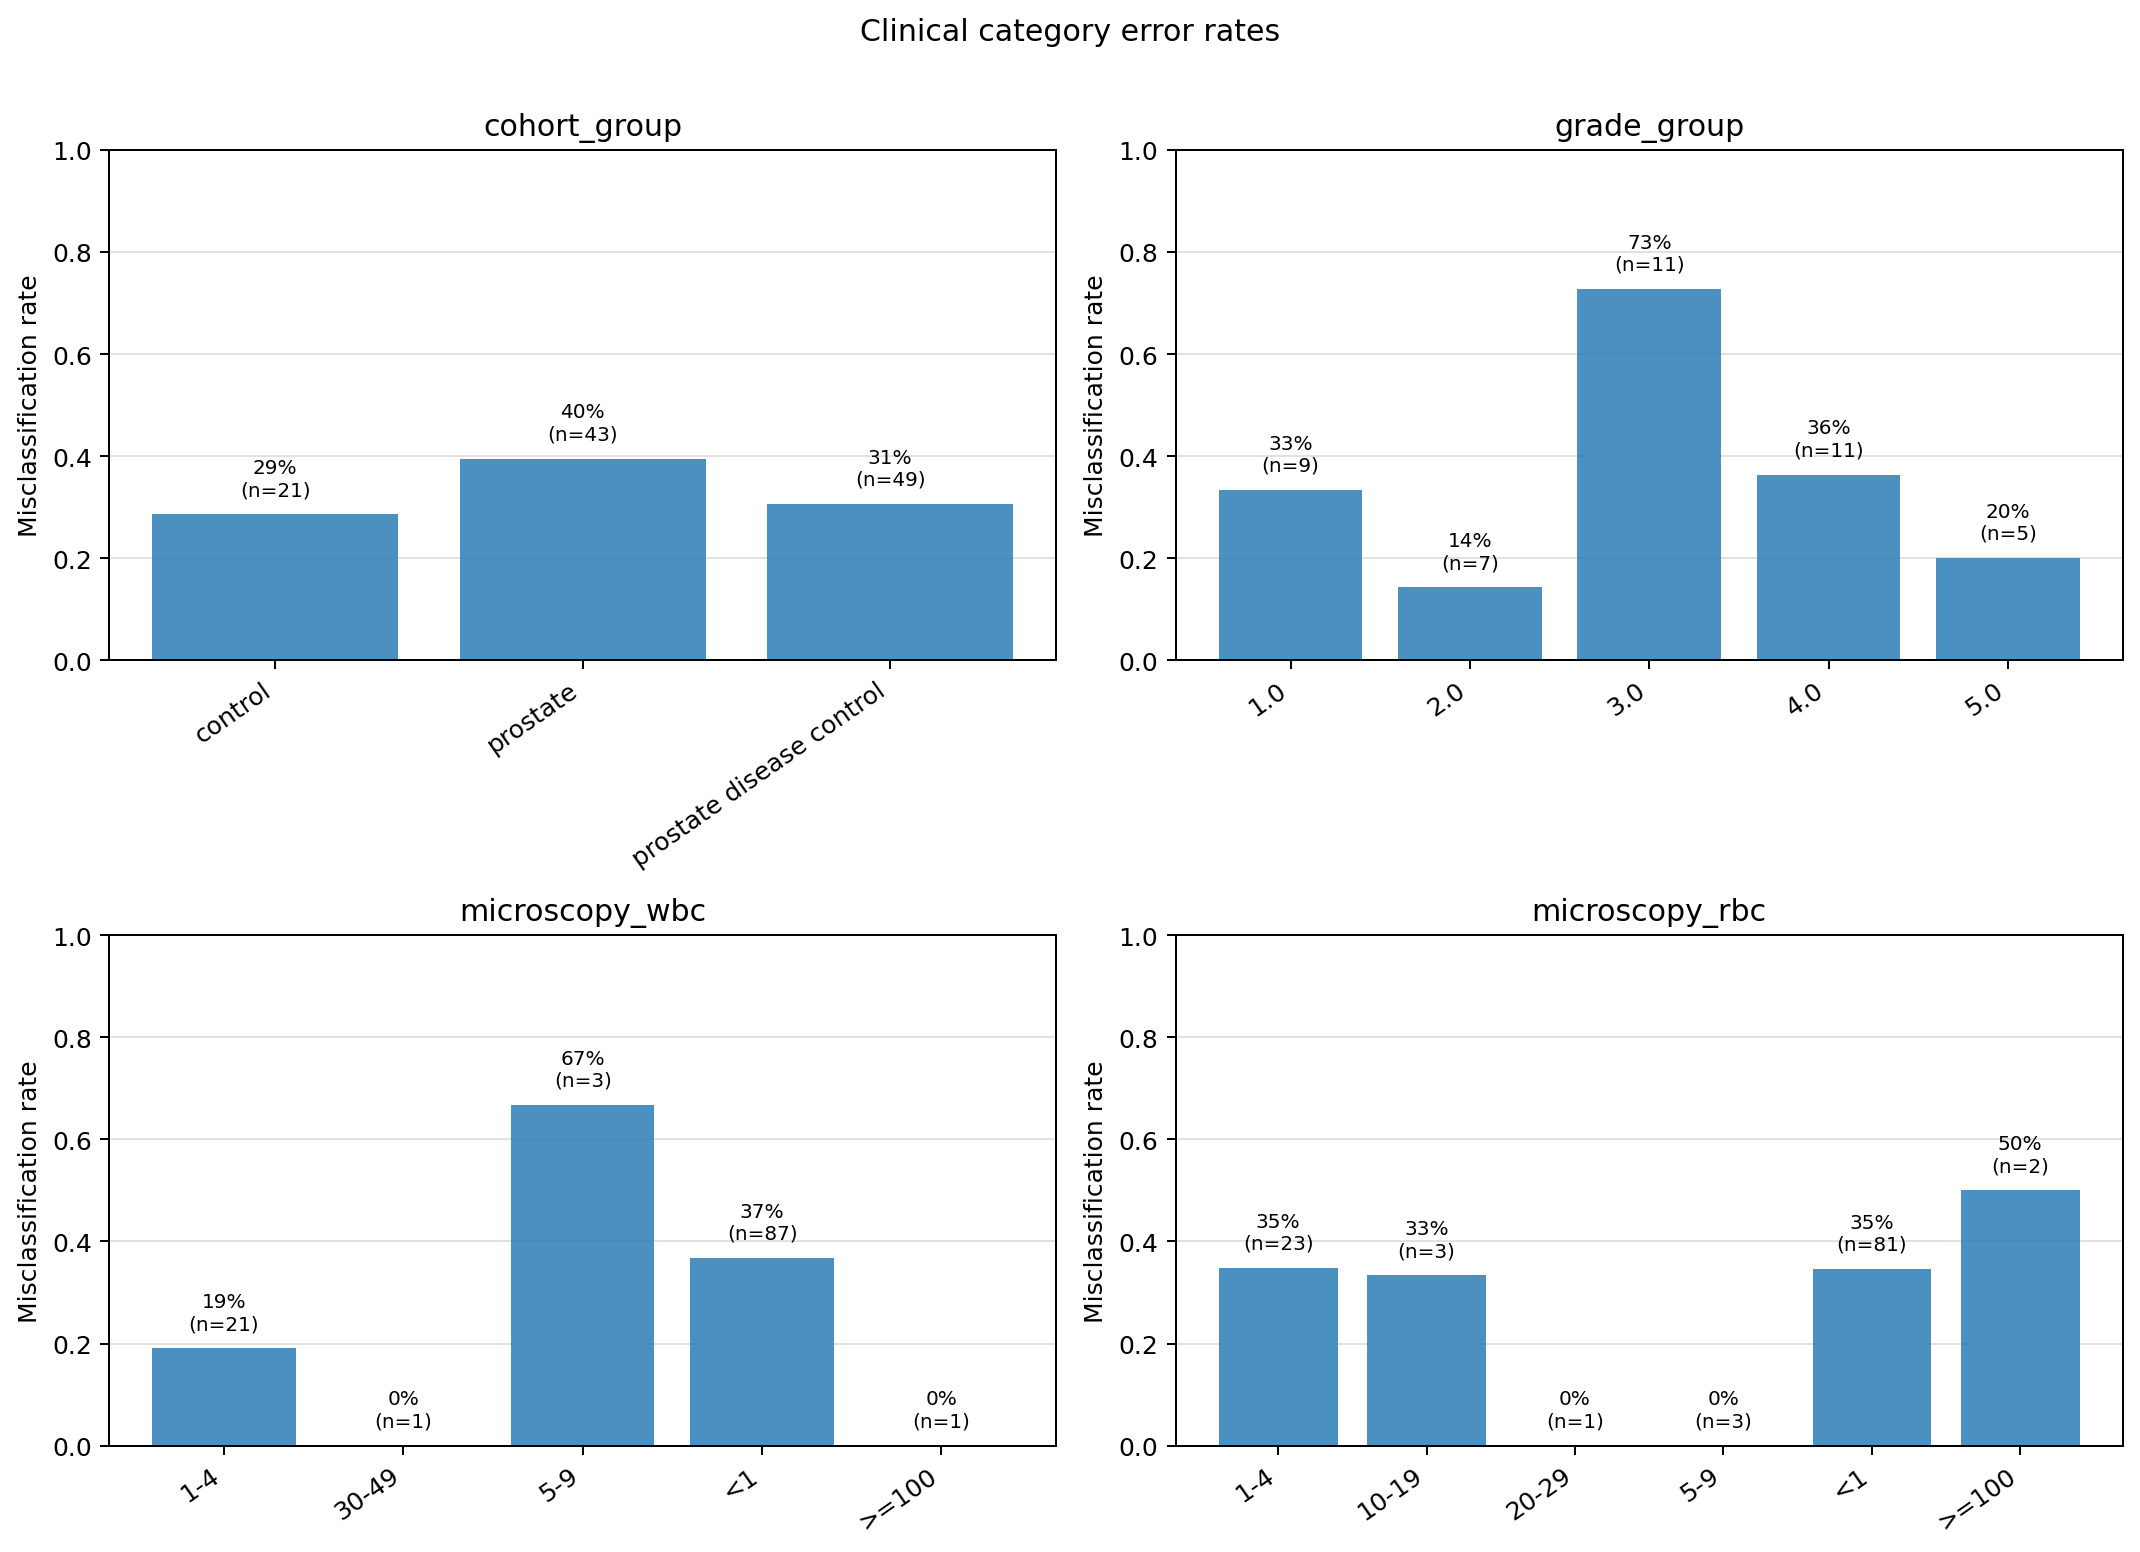

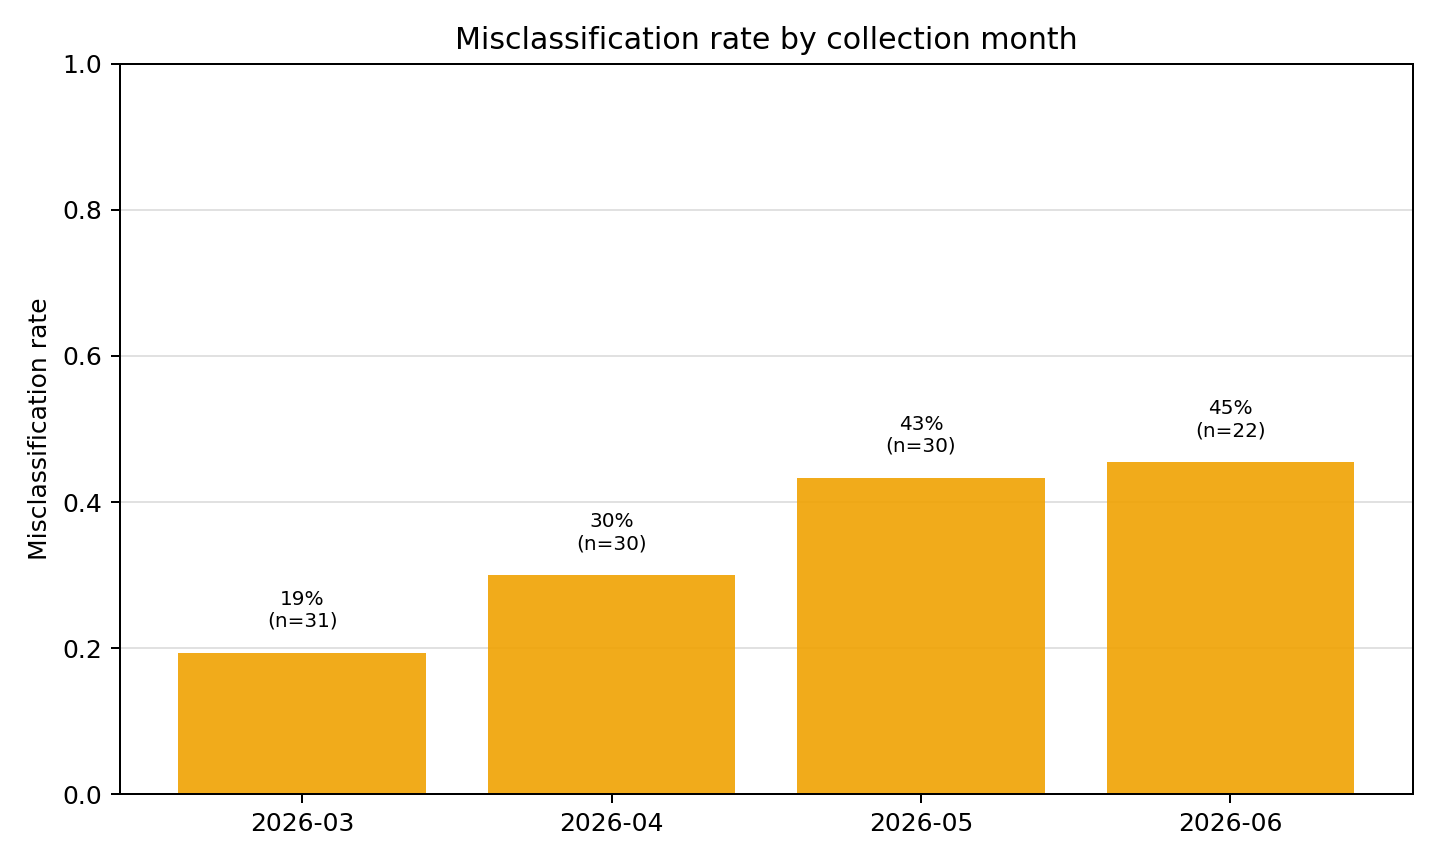

In [3]:
review_columns = [
    'analysis_row', 'review_reason', 'cohort_group', 'prediction_probability',
    'outcome', 'margin_to_threshold', 'noise_sigma_mean', 'noise_sigma_p95',
    'qc_pass_rate', 'psa_raw', 'grade_group', 'collection_month'
]
display(hard_cases.sort_values(['margin_to_threshold', 'analysis_row'])[review_columns].head(20))
for filename in [
    'fig01_probability_by_outcome.png',
    'fig02_cancer_noise_by_outcome.png',
    'fig03_clinical_category_error_rates.png',
    'fig04_collection_month_error_rate.png',
]:
    display(Image(filename=str(OUTPUT_DIR / filename)))

## Interpretation and next experiment

The repeated acquisition count is not itself evidence that the model had enough independent training information. It helps characterize within-subject repeatability and stabilize a subject representation, while the number of independent clinical labels remains 113. The observed errors are compatible with three overlapping issues: biological overlap between cancer and prostate disease control, residual within-subject spectral variability, and possible acquisition-period effects.

The next controlled comparison should evaluate spectrum-only, clinical-only, and fused models on the exact same subject-level nested folds. Clinical variables must be fitted inside each training fold, and performance should be reported by cohort, collection period, and repeat-noise stratum.